In [3]:
import numpy as np
import pandas as pd
import os
import sys
#import fileinput

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [4]:
!pwd

/Users/macbook/divtel/config


In [5]:
#remove temporary file if it exists
filePath = 'temporary_df.txt'
if os.path.exists(filePath):
    os.remove(filePath)
else:
    None

In [6]:
 # will be used to write teh output file
site='Paranal'
prod='PROD6'

In [8]:
temp = open(filePath,"w")
temp.write("object_class pos_x pos_y pos_z sphere_radius tel_id telescope_name class_id geo_code")
temp.write("\n")
with open(f'/Users/macbook/divtel/INPUTS_CTA_{prod}-array-{site}.inc', 'r') as f:
    for line in f:
        # Use continue so your code doesn't become a nested mess.
        if line[0] == '*':
            continue  
        # if this check passes, we can assume line is not a comment.
        else: 
            line=line.replace('(',' ')            
            line=line.replace(')',' ')
            line=line.replace('#',' ')
            line = " ".join(line.split())
            temp.write(f'{line}\n')
            

temp.close()

In [14]:
df = pd.read_csv ('temporary_df.txt', header=0, sep=' ', engine='python')
# removing my temporary file
os.remove(filePath)

ParserError: Expected 9 fields in line 31, saw 16

In [15]:
#cm to m conversion
df.pos_x=df['pos_x'].apply(lambda x: x*10**(-2))
df.pos_y=df['pos_y'].apply(lambda x: x*10**(-2))
df.pos_z=df['pos_z'].apply(lambda x: x*10**(-2))
df.sphere_radius=df['sphere_radius'].apply(lambda x: x*10**(-2))
df

NameError: name 'df' is not defined

In [16]:
fileName=f'CTA-{prod}_TelescopePositions{site}.txt'
if os.path.exists(fileName):
    os.remove(fileName)
else:
    None
output=open(fileName,'a+')
for i in range(len(df.telescope_name)):
    if 'LST' in df.telescope_name[i]:
        focal_lenght= 28
        camera_radius=2.15
    elif 'MST' in df.telescope_name[i]:
        focal_lenght= 16
        camera_radius=3.85
    elif 'SST' in df.telescope_name[i]:
        focal_lenght= 5.6
        camera_radius=4.45
    line=(f'{round(df.pos_x[i],2)} {round(df.pos_y[i],2)} {round(df.pos_z[i],2)} {focal_lenght} {camera_radius}')
    output.write(f'{line}\n')
output.close()

NameError: name 'df' is not defined

NameError: name 'df' is not defined

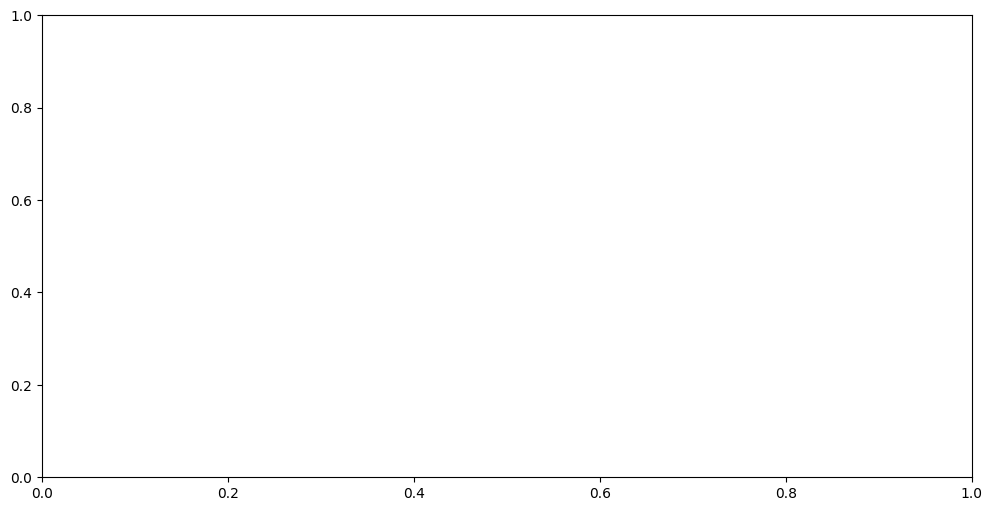

In [17]:
import matplotlib.pyplot as plt
fig = plt.subplots(figsize=(12,6))
for i,tel in enumerate(df.telescope_name):
    plt.annotate(tel,(df.pos_x[i],df.pos_y[i]+1))
    if 'LST' in tel: 
        plt.scatter(df.pos_x[i],df.pos_y[i],color='orange')
    elif 'SST' in tel: 
        plt.scatter(df.pos_x[i],df.pos_y[i],color='green')
    else:
        plt.scatter(df.pos_x[i],df.pos_y[i],color='blue')

